### Understanding Artifical Intelligence Assignment
this exercise is to explore how supervised learning models can be used to predict the price of a second hand car, 
based on the information contained in this dataset. We will also explores how unsupervised learning techniques can be used 
to identify clustering patterns in this dataset.

#### Importing Relevant Liberaries

In [179]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as  plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [180]:
file = "car_sales_data.csv"      # Assignin a varialbe to the dataset

In [181]:
#using pandas to read the data
df = pd.read_csv(file)

In [182]:
df.head() # sampling first 5 rows to ses the dataset

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [183]:
df.isna().sum()  #  cheaching to confirm the data is clean

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

### Building A model with one Numerical Variable = Engine size and Evaluting Linear or Polynomial which best fits

Task 1: Importing train test split from sklearn to slit the dataset
into test and train 8% 0f the data is to train the model
while 20% of the data is to test the outcome of the model

In [184]:
# Extract the input feature
x = df["Engine size"]
# Extract the output feature
y = df["Price"]
# The sklearn models we will be using expect
# the input, x, to be in the form of a
# 2-dimensional array.
# it has 2 dimensions.
x = x.to_numpy().reshape(-1, 1)

# We need to import the train_test_split function
# from the sklearn library
from sklearn.model_selection import train_test_split
# We can now split the x and y arrays between the
# train and test sets. we will use
# 20% of the data for the testing set, and the
# remaining 80% for the training set.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Lets check the size of the training and
# testing sets.
print("There are %d data points in the training set." % (len(x_train), ))
print("There are %d data points in the testing set." % (len(x_test), ))


There are 40000 data points in the training set.
There are 10000 data points in the testing set.


In [185]:
print(len(x_test), len(y_test))

10000 10000


We would have to import StandardScaler to rescale the values, since we are using a numerical  variable rescaling it it cruical to zero and one ro be able to obtain a mean of zero and a deviation of 1

In [186]:
# immporting standard scaler from sklearn to reshape

from sklearn.preprocessing import StandardScaler

scale = StandardScaler()   # create the scaler

scale.fit(x_train)   # rescaling to ebale us find the mean and standard deviation

# Now apply the standard scaler transformation
# to both the training and the testing sets
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)


In [187]:
#validating the split before trainig
print(len(x_train_scaled),len( x_test_scaled ))

print (len(y_train), len(y_test))


40000 10000
40000 10000


In [188]:
from sklearn.linear_model  import LinearRegression

price_linear = LinearRegression()    #creates an instant model regresssion
price_linear.fit(x_train_scaled, y_train)   #fit the model tot the training data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [189]:
# Get the gradient and the intercept

gradient = price_linear.coef_[0]
intercept = price_linear.intercept_

# printing their coffients

print(f'the gradient: {gradient}')
print(f'the intercept: {intercept}')

the gradient: 6575.659995991372
the intercept: 13854.6287


Checking the relative errors, to examine how the model is responding, we have the mean absoulute error reflecting the unit differents of the real price,  also the mean squared error. But we also  see  that the R2 is not really good, its show the perfomance of the model  is bad

In [190]:
#importing the metrics from sklearn

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Use the final, trained model to predict the
# outputs price of the second hand car
# the testing dataset.
price_pred = price_linear.predict(x_test_scaled)

mean_abs = mean_absolute_error(y_test, price_pred)   # obtaining mean absolute error
 
mean_sq = mean_squared_error(y_test, price_pred)      # obtaining mean squared error

rms = np.sqrt(mean_sq)  # root mean square (rms) is square root of mean_square

R2 = r2_score(y_test, price_pred)

## printning all the errors
print('mean absolute error:', mean_abs)
print('mean square error:', mean_sq)
print('r2 score:', R2)
print('Root mean square:', rms)

mean absolute error: 10817.491562557907
mean square error: 230499154.45279127
r2 score: 0.15062562461380213
Root mean square: 15182.198604049128


Creating the model for linear regression to compare the relationship, and which line best fits

In [191]:
df['Engine size'].min()       #checking the max of Engine size to create a sufficient range

np.float64(1.0)

In [192]:
# Create an array of values covering the range of
# Engine size that we found in the dataset, i.e. from 0 to 5.0
# array so it has 2 dimensions.
x_fit = np.arange(0, 5.5, 0.01).reshape(-1, 1)
# Apply the standardisation transformation using StandardScaler
# training and testing data.
x_fit_scaled = scale.transform(x_fit)
# Apply the trained model to this scaled input array.

y_fit = price_linear.predict(x_fit_scaled)

Using Seaborn to plot the scatterd and fit the regression line

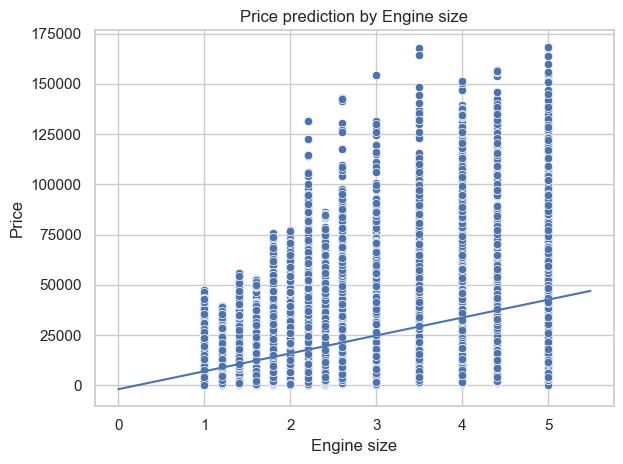

In [193]:


sns.scatterplot(data = df, x='Engine size', y = 'Price')  
# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)
plt.xlabel('Engine size')  #label on X-axis
plt.ylabel('Price')   #label on y-axis
plt.title('Price prediction by Engine size')

plt.tight_layout()  # prevents clipping
plt.savefig('ppPrice_prediction_by_Year_of_Engine_size.png', dpi=200, bbox_inches='tight')

plt.show()              #showing the plot on the terminal

From the chart we can see that the lines are not okay and the fit is not the best, this futher shows us why the Error values are bad

#### Running the model for the polynomial to see the best fit still using Engine size as the feature

In [194]:
# Extract the input feature
x = df["Engine size"]
# Extract the output feature
y = df["Price"]
# The sklearn models we will be using expect
# the input, x, to be in the form of a
# 2-dimensional array.
# it has 2 dimensions.
x = x.to_numpy().reshape(-1, 1)

# We need to import the train_test_split function
# from the sklearn library
from sklearn.model_selection import train_test_split
# We can now split the x and y arrays between the
# train and test sets. we will use
# 20% of the data for the testing set, and the
# remaining 80% for the training set.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Lets check the size of the training and
# testing sets.
scale = StandardScaler()
# Fit the standard scaler to the input data that
# we have in x_train.
scale.fit(x_train)
# Now apply the standard scaler transformation
# to both the training and the testing sets.
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

we are going to create the polynomial to which to comaper the difference as against the linear regression, we would achive this by importing the relivant polynomial features from the sklearn library 

In [195]:
# Import the PolynomialFeatures class from the
# sklearn library.
from sklearn.preprocessing import PolynomialFeatures

# Create an instance of the PolynomialFeatures class.
poly = PolynomialFeatures(degree = 2, include_bias = False)

# Now apply this PolynomialFeatures transformation to
# the scaled input data from the training set. The result
# will give us a 2-dimensional array, where the first column
# contains the terms for x and the second column contains
# the terms for x**2.
x_poly = poly.fit_transform(x_train_scaled)


Creating the LinearRegression model instance

In [196]:
# Create an instance of the LinearRegression model.
price_poly = LinearRegression()
# Fit the model to the training data.
price_poly.fit(x_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [197]:
# Get the fit coefficients from the
# best-fit model.
coefficients = price_poly.coef_
intercept = price_poly.intercept_
# Print the coefficients
print("coefficients: ", coefficients)
print("intercept: ", intercept)

coefficients:  [6079.69940101  238.69551851]
intercept:  13615.933181493827


Note that we now have two values in “coefficient”, the first coefficient multiplies the 𝑥 term and the second coefficient multiplies the 𝑥2 term.
We also have the intercept (i.e. the constant term) as before. Now lets calculate the evaluation metrics for this model.


In [198]:
# the testing dataset. We first need to create
# the polynomial features from the scaled
# inputs features in the testing set, and then
# we can use this with the final trained model
# to get the predicted life expectancies.
x_test_poly = poly.fit_transform(x_test_scaled)
price_pred = price_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, price_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, price_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, price_pred)
# Print the results of these metrics.
print("Mean absolute error: ", mean_abs)
print("Mean squared error: ", mean_squared)
print("Root mean squared error: ", rms_error)
print("R2: ", R2)

Mean absolute error:  10807.262347148684
Mean squared error:  230326165.99946904
Root mean squared error:  15176.500452985498
R2:  0.15126307580028653


Checking the relative errors, to examine how the model is responding, we have the mean absoulute error reflecting the unit differents of the real price, also the mean squared error. But we also see that the R2 is not really good, its show the perfomance of the model is bad, it shows that using the Engine size to predict price isnt a good feature

We would plot the polynomial chat to see the representation on the chat

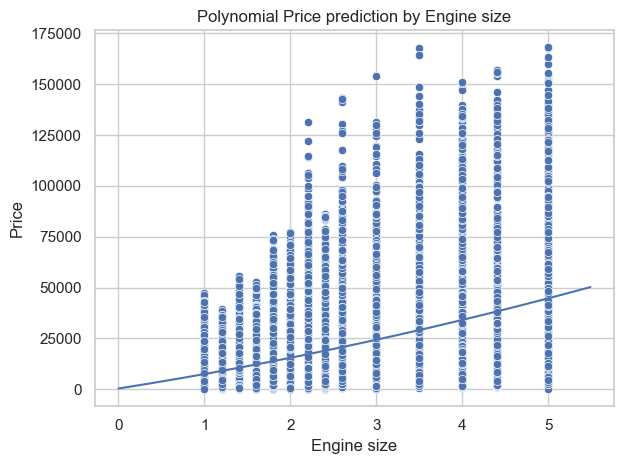

In [199]:
 #Create an array of values covering the range
# of Engine size that we found in the dataset, i.e.
# from 0 to 5.0.
x_fit = np.arange(0, 5.5, 0.01).reshape(-1, 1)
# Apply the standardisation transformation using

# the same StandardScaler that we used on the
# training and testing data.
x_fit_scaled = scale.transform(x_fit)
# Create the polyomial features and apply them
# to the trained model. This will give us the
# y-values for the best-fit line.
x_fit_poly = poly.fit_transform(x_fit_scaled)
y_fit = price_poly.predict(x_fit_poly)
# Use seaborn to create a scatter plot of price
# versus Engine size.
sns.scatterplot(data = df, x = "Engine size", y = "Price")
# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)
# Label both axes
plt.xlabel("Engine size")
plt.ylabel("Price")
plt.title('Polynomial Price prediction by Engine size')
plt.tight_layout()  # prevents clipping

plt.savefig('Polynomial_Price_prediction_by_Engine Size.png', dpi=200, bbox_inches='tight')

# Show the plot
plt.show()

### Building A model with one Numerical Variable = Year of manufacture and Evaluting Linear or Polynomial which best fits

Task 1.1: Importing train test split from sklearn to slit the dataset
into test and train 8% 0f the data is to train the model
while 20% of the data is to test the outcome of the model

This Task involues using Year of manufacture as the Feature


In [200]:
x = df['Year of manufacture']
# Extract the output feature
y = df["Price"]

x = x.to_numpy().reshape(-1, 1)

# Split the x and y data between the
# training and testing datasets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that
# we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation
# to both the training and the testing sets.
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

# Create an instance of the model
price_linear = LinearRegression()
# Fit the model to the training data.
price_linear.fit(x_train_scaled, y_train)
# Get the fit coefficients from the
# best-fit model.

intercept = price_linear.intercept_
coefficients = price_linear.coef_
# Print the coefficients.
print("coefficients: ", coefficients)
print("intercept: ", intercept)

# Use the final, trained model to predict the
# outputs (life expectancies) for countries in
# the testing dataset.
price_pred = price_linear.predict(x_test_scaled)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, price_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, price_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, price_pred)



coefficients:  [11711.62203633]
intercept:  13854.628699999997


In [201]:
# Print the results of these metrics.
print("Mean absolute error: ", mean_abs)
print("Mean squared error: ", mean_squared)
print("Root mean squared error: ", rms_error)
print("R2: ", R2)

Mean absolute error:  7031.0392086748525
Mean squared error:  132678999.94793086
Root mean squared error:  11518.637069893766
R2:  0.5110865244812854


Checking the relative errors, to examine how the model is responding, we have the mean absoulute error reflecting the unit differents of the real price, also the mean squared error. But we also see that the R2 is good, its show the perfomance of the model is responding positively when we use the manufacture data to make the prediction, compared to using Engine size, the R2 is closer to 1

We would plot the LinearRegression chat to see how the best fit

In [202]:
# df['Year of manufacture'].min()
df['Year of manufacture'].max()

np.int64(2022)

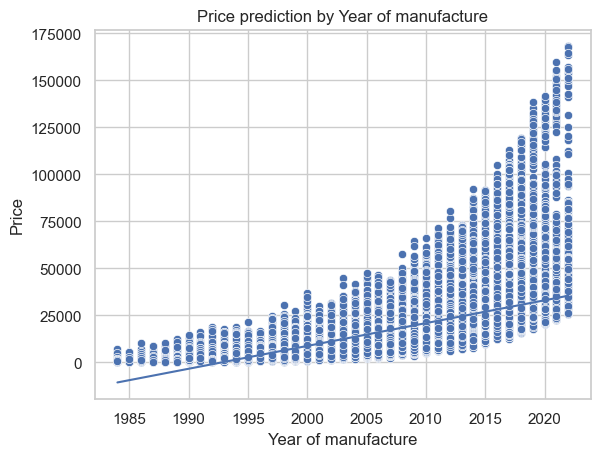

In [203]:
# Create an array of values covering the range of
# Engine size that we found in the dataset, i.e. from 1984 to 2023
# array so it has 2 dimensions.
x_fit = np.arange(1984, 2023, 1).reshape(-1, 1)
# Apply the standardisation transformation using StandardScaler
# training and testing data.
x_fit_scaled = scale.transform(x_fit)
# Apply the trained model to this scaled input array.

y_fit = price_linear.predict(x_fit_scaled)

sns.scatterplot(data = df, x='Year of manufacture', y = 'Price')  
# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)
plt.xlabel('Year of manufacture')  #label on X-axis
plt.ylabel('Price')        #label on y-axis
plt.title('Price prediction by Year of manufacture')
plt.savefig('Price_prediction_by_Year_of_manufacture.png', dpi=300, bbox_inches='tight')

plt.show() 

Using LinearRegression, the chats seems not too allienged 

We would plot the polynomial chat to see the representation on the chat and the compareison with LiinearRegression

In [204]:
# Create an instance of the PolynomialFeatures class.
poly = PolynomialFeatures(degree = 2, include_bias = False)

# Now apply this PolynomialFeatures transformation to
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
price_poly = LinearRegression()
# Fit the model to the training data.
price_poly.fit(x_poly, y_train)

# Get the fit coefficients from the
# best-fit model.
coefficients = price_poly.coef_
intercept = price_poly.intercept_
# Print the coefficients
print("coefficients: ", coefficients)
print("intercept: ", intercept)

# the testing dataset. We first need to create
# the polynomial features from the scaled
# inputs features in the testing set, and then
# we can use this with the final trained model
# to get the predicted life expectancies.
x_test_poly = poly.fit_transform(x_test_scaled)
price_pred = price_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, price_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, price_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, price_pred)


coefficients:  [12065.80671724  5281.89564916]
intercept:  8572.733050839153


In [205]:
# Print the results of these metrics.
print("Mean absolute error: ", mean_abs)
print("Mean squared error: ", mean_squared)
print("Root mean squared error: ", rms_error)
print("R2: ", R2)

Mean absolute error:  5387.109074986993
Mean squared error:  105993894.20194323
Root mean squared error:  10295.33361295025
R2:  0.6094194015754401


Creating the polynomial chart and printing on the terminal

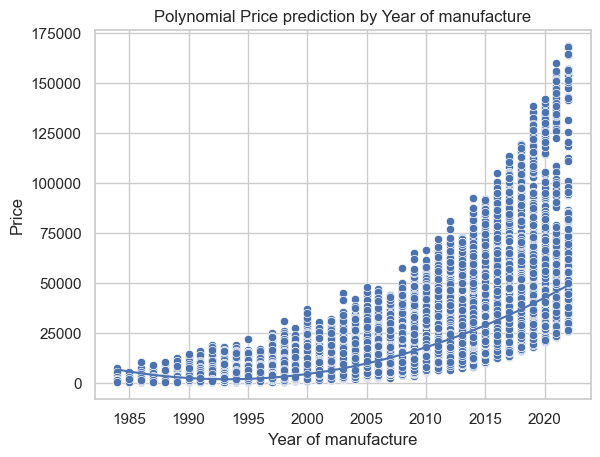

In [206]:
 #Create an array of values covering the range
# of Engine size that we found in the dataset, i.e.
# from 1984 to 2022 + 1
x_fit = np.arange(1984, 2023, 1).reshape(-1, 1)
# Apply the standardisation transformation using

# the same StandardScaler that we used on the
# training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Create the polyomial features and apply them
# to the trained model. This will give us the
# y-values for the best-fit line.
x_fit_poly = poly.fit_transform(x_fit_scaled)
y_fit = price_poly.predict(x_fit_poly)

# Use seaborn to create a scatter plot of price against Year of manufacture.
sns.scatterplot(data = df, x = "Year of manufacture", y = "Price")

# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Year of manufacture")
plt.ylabel("Price")
plt.title('Polynomial Price prediction by Year of manufacture')
plt.savefig('Polynomial Price_prediction_by_Year_of_manufacture.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

### Building A model with one Numerical Variable = Milage and Evaluting Linear or Polynomial which best fits
Task 1.2: Importing train test split from sklearn to slit the dataset into test and train 8% 0f the data is to train the model while 20% of the data is to test the outcome of the model

This Task involues using Mileage as the Feature

In [207]:
x = df['Mileage']
# Extract the output feature
y = df["Price"]

x = x.to_numpy().reshape(-1, 1)

# Split the x and y data between the
# training and testing datasets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that
# we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation
# to both the training and the testing sets.
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

# Create an instance of the model
price_linear = LinearRegression()
# Fit the model to the training data.
price_linear.fit(x_train_scaled, y_train)
# Get the fit coefficients from the
# best-fit model.

intercept = price_linear.intercept_
coefficients = price_linear.coef_
# Print the coefficients.
print("coefficients: ", coefficients)
print("intercept: ", intercept)

# Use the final, trained model to predict the
# outputs (life expectancies) for countries in
# the testing dataset.
price_pred = price_linear.predict(x_test_scaled)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, price_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, price_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, price_pred)



coefficients:  [-10374.07544571]
intercept:  13854.6287


In [208]:
# Print the results of these metrics.
print("Mean absolute error: ", mean_abs)
print("Mean squared error: ", mean_squared)
print("Root mean squared error: ", rms_error)
print("R2: ", R2)

Mean absolute error:  7964.78467002469
Mean squared error:  162468566.87254104
Root mean squared error:  12746.315815659875
R2:  0.4013139100884707


Checking the relative errors, to examine how the model is responding, we have the mean absoulute error reflecting the unit differents of the real price, also the mean squared error. But we also see that the R2 is so good, its show the perfomance of the model is responding positively when we use the Mileage to make the prediction, compared to using Engine size, but  comapred to Year of manufacture its not really good the R2 is closer to 1

We would plot the LinearRegression chat to see how the best fit



In [209]:
df['Mileage'].max()

np.int64(453537)

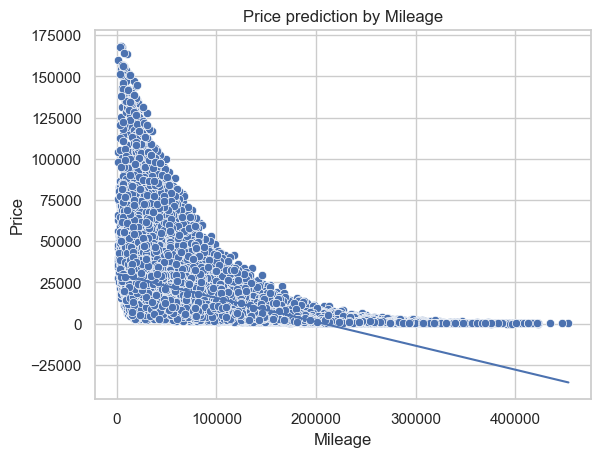

In [210]:
# Create an array of values covering the range of
# Engine size that we found in the dataset, i.e. from 630 to 453537 +1, using +1 to ensure the data point covers for all poitns
# array so it has 2 dimensions.
x_fit = np.arange(630, 453538, 1).reshape(-1, 1)
# Apply the standardisation transformation using StandardScaler
# training and testing data.

x_fit_scaled = scale.transform(x_fit)
# Apply the trained model to this scaled input array.

y_fit = price_linear.predict(x_fit_scaled)

sns.scatterplot(data = df, x='Mileage', y = 'Price')  
# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)

plt.xlabel('Mileage')  #label on X-axis
plt.ylabel('Price')
plt.title('Price prediction by Mileage')
plt.savefig('Price_prediction_by_Mileage.png', dpi=300, bbox_inches='tight')

#show plot
plt.show()

Seeing the plot , the LinearRegrreession plot does not fit any line properly, so we would try the polynomial to see how it reacts with the data and proviide a better fit

In [211]:
# Create an instance of the PolynomialFeatures class.
poly = PolynomialFeatures(degree = 2, include_bias = False)

# Now apply this PolynomialFeatures transformation to
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
price_poly = LinearRegression()
# Fit the model to the training data.
price_poly.fit(x_poly, y_train)

# Get the fit coefficients from the
# best-fit model.
coefficients = price_poly.coef_
intercept = price_poly.intercept_
# Print the coefficients
print("coefficients: ", coefficients)
print("intercept: ", intercept)

# the testing dataset. We first need to create
# the polynomial features from the scaled
# inputs features in the testing set, and then
# we can use this with the final trained model
# to get the predicted life expectancies.
x_test_poly = poly.fit_transform(x_test_scaled)
price_pred = price_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, price_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, price_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, price_pred)

coefficients:  [-13630.81884183   4476.1506104 ]
intercept:  9378.478089598233


In [212]:
# Print the results of these metrics.
print("Mean absolute error: ", mean_abs)
print("Mean squared error: ", mean_squared)
print("Root mean squared error: ", rms_error)
print("R2: ", R2)

Mean absolute error:  6409.911605271263
Mean squared error:  129620312.16261968
Root mean squared error:  11385.091662460152
R2:  0.5223575898060919


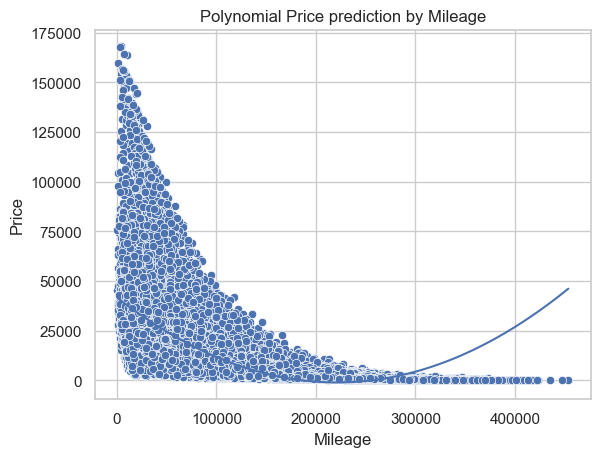

In [213]:
#Create an array of values covering the range
# of Engine size that we found in the dataset, i.e.
# from 630,to 453537 + 1
x_fit = np.arange(630, 453538, 1).reshape(-1, 1)
# Apply the standardisation transformation using

# the same StandardScaler that we used on the
# training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Create the polyomial features and apply them
# to the trained model. This will give us the
# y-values for the best-fit line.
x_fit_poly = poly.fit_transform(x_fit_scaled)
y_fit = price_poly.predict(x_fit_poly)

# Use seaborn to create a scatter plot of price against Year of manufacture.
sns.scatterplot(data = df, x = "Mileage", y = "Price")

# Plot the best-fit line from
# the trained model
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.title('Polynomial Price prediction by Mileage')

plt.savefig('Polynomia_Price_prediction_by_Mileage.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show() 

The curve picked some cleaner best fit, this is not the cleanest of data point and prediction

## Task 2
Createing a model with multiple variable to see how the model improves, we would be using Engine size, year of manufacture and Mileage as the features

In [214]:
# Extracting the features
features = ['Engine size', 'Year of manufacture', 'Mileage']

x = df[features]
# Extract the output feature
y = df["Price"]

# Split the x and y data between the
# training and testing datasets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that
# we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation
# to both the training and the testing sets.
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

# Create an instance of the model
price_linear = LinearRegression()

# Fit the model to the training data.
price_linear.fit(x_train_scaled, y_train)

# Get the fit coefficients from the
# best-fit model.
intercept = price_linear.intercept_
coefficients = price_linear.coef_

# Print the coefficients.
print("coefficients: ", coefficients)
print("intercept: ", intercept)

# Use the final, trained model to predict the
# outputs (life expectancies) for countries in
# the testing dataset.
price_pred = price_linear.predict(x_test_scaled)

# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, price_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, price_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, price_pred)


# Print the results of these metrics.
print("Mean absolute error: ", mean_abs)
print("Mean squared error: ", mean_squared)
print("Root mean squared error: ", rms_error)
print("R2: ", R2)

coefficients:  [ 6594.02448017  9520.41488938 -2720.41736808]
intercept:  13854.628699999997
Mean absolute error:  6091.458141656208
Mean squared error:  89158615.76017143
Root mean squared error:  9442.38400829851
R2:  0.671456306417368


ploting with multiple varible the errors look okay, R2 is  0.671456306417368, which is close to 1.
    we would have to plot these to see the points that best fits

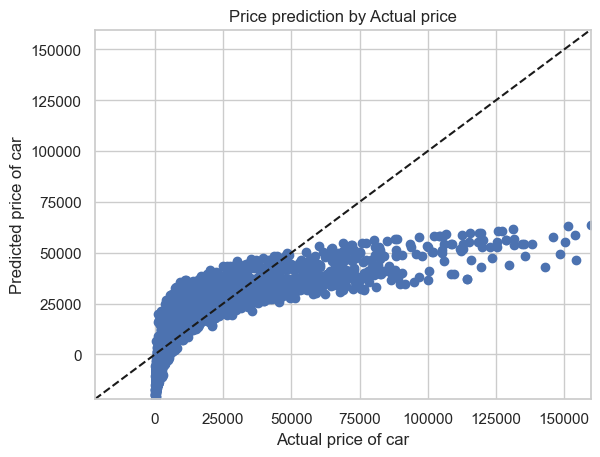

In [215]:
# Create a scatterplot comparing the predicted
# and actual values of the output variable.
plt.scatter(y_test, price_pred)
# Add a straight diagonal line to the plot.
# If the model is performing well, the data
# points should lie along this line, meaning
# that the predicted values are equal to the
# actual values
min_val = min(y_test.min(), price_pred.min())
max_val = max(y_test.max(), price_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'k--')

# Label both axes.
plt.xlabel("Actual price of car")
plt.ylabel("Predicted price of car")
# Limit the range of values on both axes 
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.title('Price prediction by Actual price')

plt.savefig('Multiple_numerical_variable_Price_prediction_by_Acutual_price.png', dpi=300, bbox_inches='tight')
plt.show()


In [216]:
print(df.columns)

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price'],
      dtype='object')


we had to  use the min value of y_test, price_pred and the max value of y_test and price_pred to determine the acuracy of the predicition, this shows there are lots of scattered prices below the price range lim lines it tells us the the model is having some issues with its prediction

But using multiple numerical varible made a better prediction when compaered to single varibles

### Task 3
Creating a working model using RandomForest to convert catergorical varible into numerical varibles, to effectively build the model and better predict prices.
To also see how the model reacts to the predictions.

In [217]:

# Encode categorical variables using One-Hot Encoding
df = pd.get_dummies(df, columns=['Manufacturer','Model','Fuel type'], drop_first=True)

# Split into features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


# Make predictions
y_pred = rf.predict(X_test)


# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


In [218]:
# printing the results of the error metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")


Mean Absolute Error (MAE): 292.39
Mean Squared Error (MSE): 415044.78
Root Mean Squared Error (RMSE): 644.24
R2 Score: 1.00


When using Random forest for this prediction, the evaluation metrics was way better compared to using single varibaleble and the R2 score is 1.0, which shows the model worked very well

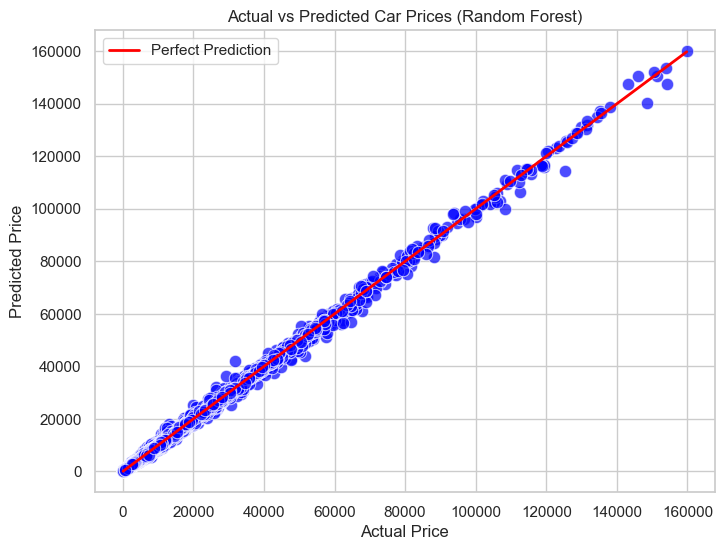

In [219]:
results = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': y_pred
})

# Scatterplot with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(x='Actual_Price', y='Predicted_Price', data=results, s=80, color='blue', alpha=0.7)
sns.lineplot(x='Actual_Price', y='Actual_Price', data=results, color='red', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices (Random Forest)")
plt.legend()
plt.savefig('Price_prediction_by_Actual.png', dpi=300, bbox_inches= 'tight')
plt.show()

### Task 4
Building the Artifical Neural  Network, import kerras from tensor flow, callbacks and earlystop to help us prevent overfiiting

In [220]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Defining the features and setting target

# Price is the target variable
X = df.drop('Price', axis=1)   # already one-hot encoded, dropping price from the data set and using the rest column
y = df['Price']



# Slipting the data set into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# Scaling the features which is important to ANN

# ANN requires scaled numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Building the ANN model

model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=64,               # number of neurons
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

# Second hidden layer
model.add(Dense(units=32, activation='relu'))

# Output layer (1 neuron for regression)
model.add(Dense(units=1))



# compling the model
model.compile(
    optimizer='adam',
    loss='mse'   # Mean Squared Error for regression
)



# EARLY STOPPING (PREVENT OVERFITTING)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)



# TRAIN THE MODEL
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)



# MAKE PREDICTIONS
price_pred_ann = model.predict(X_test_scaled).flatten()

# EVALUATE MODEL PERFORMANCE
mae = mean_absolute_error(y_test, price_pred_ann)
mse = mean_squared_error(y_test, price_pred_ann)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, price_pred_ann)

Epoch 1/200


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 216308752.0000 - val_loss: 54361188.0000
Epoch 2/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 42048668.0000 - val_loss: 30383274.0000
Epoch 3/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 27296722.0000 - val_loss: 21510158.0000
Epoch 4/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 19636800.0000 - val_loss: 15009229.0000
Epoch 5/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 14161837.0000 - val_loss: 10833996.0000
Epoch 6/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 10272874.0000 - val_loss: 7548371.5000
Epoch 7/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7566888.0000 - val_loss: 5508129.0000
Epoch 8/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5642558.5000 - val_loss: 4066716.0000
Epoch 9/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4235033.5000 - val_loss: 3073581.5000
Epoch 10/200
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3228402.0000 - val_loss: 23

In [221]:
print(f"ANN Model Performance:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

ANN Model Performance:
MAE: 123.10
MSE: 37848.46
RMSE: 194.55
R2 Score: 1.00


Plotting the prediction with Seaborn

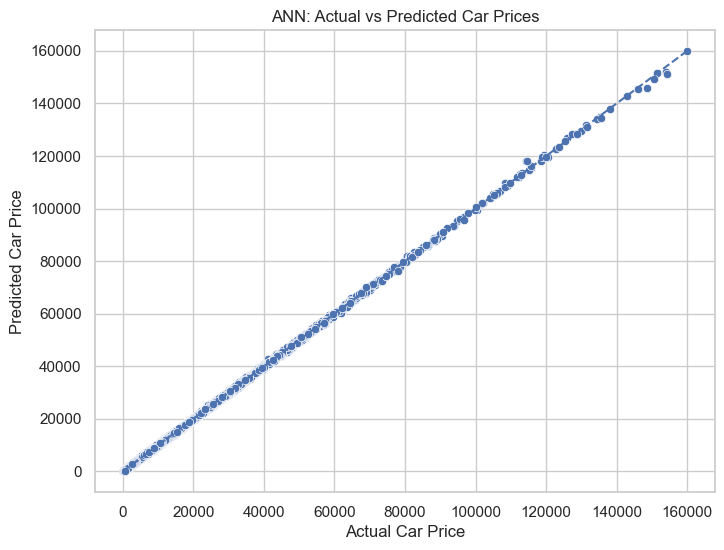

In [222]:

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (ANN)': price_pred_ann
})

# Set seaborn style
sns.set(style="whitegrid")

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x='Actual Price',
    y='Predicted Price (ANN)'
)

# Perfect prediction reference line
max_price = max(plot_df['Actual Price'].max(), plot_df['Predicted Price (ANN)'].max())
min_price = min(plot_df['Actual Price'].min(), plot_df['Predicted Price (ANN)'].min())

plt.plot([min_price, max_price], [min_price, max_price], linestyle='--')

# Labels and title
plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")
plt.title("ANN: Actual vs Predicted Car Prices")

plt.savefig('Price_prediction_by_Actual_price.png', dpi=300, bbox_inches='tight')


plt.show()


Using Airtifical Neural Network, the Metrics erros looks good and the R2 is exactly 1, which means the prediction is very okay, the plots looks better comapered to RandomForest, the prediction from RandomForest it alittle bit scattered around the limit lines, but with ANN its close to perfection

The plot shows the relationship between the actual and predicted car prices using the ANN model. The diagonal line represents perfect predictions. Most data points lie close to this line, indicating reasonable predictive performance, although some dispersion is observed for higher-priced vehicles.

#### Task 5 Comparison of Models created and which model perfomed best

Several supervised learning models were developed and evaluated to predict car prices using the available dataset. These included a single-variable linear regression model and polynomial models, a multiple-variable regression model, a Random Forest regressor, and an Artificial Neural Network (ANN). Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score, alongside visual inspection of prediction plots.

#### Single-Variable Model Performance

The single-variable model, which used only one predictor (such as mileage or year of manufacture and Engine size), demonstrated limited predictive capability.

High MAE and RMSE, indicating large average prediction errors

Low R² score, showing that a significant proportion of price variation was unexplained

Scatter plots revealed wide dispersion from the perfect-prediction line

This result was expected, as car price is influenced by multiple interacting factors, and relying on a single feature oversimplifies the problem.

#### Multiple Numerical Variable Model Performance

The multipleNumerical variable regression model incorporated several predictors such as engine size, mileage, year of manufacture, and fuel type.

Improved MAE and RMSE compared to the single-variable model

Higher R² score, indicating better explanatory power

Predictions showed closer alignment with actual prices

However, linear regression assumes linear relationships between features and price and polynomial plots, which limits its ability to capture complex interactions present in real-world car valuation.

#### Random Forest Model Performance

The Random Forest model significantly outperformed both linear models.

Lower MAE and RMSE, demonstrating strong predictive accuracy

High R² score, indicating effective modelling of non-linear relationships

Robust to outliers and feature interactions

Random Forest performed particularly well due to its ensemble nature and ability to handle mixed data types. However, some limitations were observed:

Reduced performance stability for extreme price values

Less smooth generalisation when predicting unseen combinations of features

#### Artificial Neural Network (ANN) Performance

The ANN achieved Same metrics performance as RandomForest.

However Actual vs predicted price plots showed predictions tightly clustered around the ideal diagonal line

Residual plots indicated fewer systematic errors across the price range

The ANN’s advantage lies in its ability to:

Capture complex, non-linear relationships

Learn feature interactions automatically

Adapt to patterns that traditional models cannot easily represent

While Random Forest performed strongly, the ANN consistently produced:

More accurate predictions across low-, mid-, and high-price vehicles

Better generalisation when using all available features

The use of feature scaling, multiple hidden layers, and early stopping further enhanced ANN performance and prevented overfitting.

Conclusion

Based on quantitative evaluation metrics and visual analysis, the Artificial Neural Network is the best model for predicting car prices in this study. While simpler models provide useful baselines and Random Forest offers strong performance, the ANN’s superior ability to model complex relationships makes it the most effective approach when all available features are utilised.



### Task 6
Creating a  clustered algorithim for car sales, using K-means and numerical Varible from the data set

in thee first combinationation we used, Engine Size and year of  manufacture

In [223]:
# import libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

In [224]:
# Extract the input features
feature = ["Engine size", "Year of manufacture"]
x = df[feature]

# Import the StandardScaler class from sklearn
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that
# we have in x. This will find the mean and standard
# deviation of each column in x.
scale.fit(x)

# Now we can apply the standard scaler transformation
# to re-scale each column in x.
x_scaled = scale.transform(x)

# Import the k-Means model
from sklearn.cluster import KMeans

# Create a list to record the inertia
# for each value of k.
inertia = []

# Define the range of values of k
# that we will use.

k_range = range(1, 11)
# Loop through the possible values of k
for k in k_range:
# Initialise the model
    kmeans = KMeans(n_clusters = k, random_state = 42)
# Fit the model to the scaled data
    kmeans.fit(x_scaled)
# Record the inertia
    inertia.append(kmeans.inertia_)

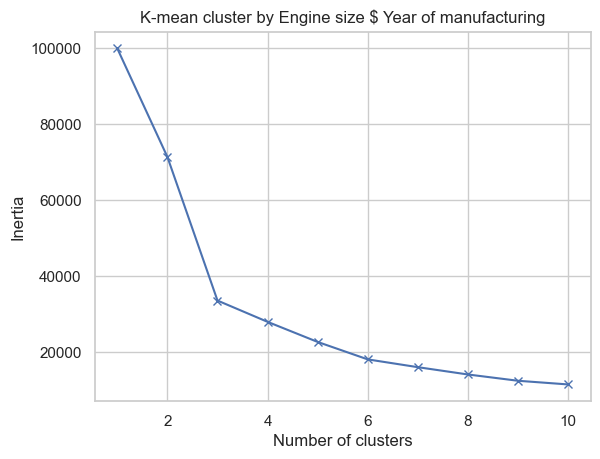

In [225]:
# Use matplotlib to plot the inertia versus k
plt.plot(k_range, inertia, 'bx-')
# Label the axes
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.title("K-mean cluster by Engine size $ Year of manufacturing")

plt.savefig('K-mean cluster by Engine size $ Year of manufacturing.png', dpi=300, bbox_inches='tight')
# Show the figure
plt.show()


In [226]:
# Fit the final k-Means model
# with our chosen k=3
kmeans_final = KMeans(n_clusters = 3, random_state = 42)

kmeans_final.fit(x_scaled)
# Use this fit to predict the cluster labels for
# each data point in the dataset.
cluster_labels_pred = kmeans_final.predict(x_scaled)

# Import the internal measures
from sklearn.metrics import davies_bouldin_score, silhouette_score
# Calculate the Davies-Bouldin index
db_score = davies_bouldin_score(x_scaled, cluster_labels_pred)
# Calculate the Silhouette coefficient
s_score = silhouette_score(x_scaled, cluster_labels_pred)
# Print the results
print("Davies Bouldin Index: %.4f" % (db_score, ))
print("Silhouette Coefficient: %.4f" % (s_score, ))


Davies Bouldin Index: 0.7525
Silhouette Coefficient: 0.4597


From this cominationation it is clear that the clustering is not good enough, beacuase the davies Bouldin Index is closer to 1 which is very high and the Silhouette coefficient is far away from 1 

We applied K-Means clustering with k=3 on the dataset containing engine size, and year of manufacture. The resulting silhouette score was 0.4597. This indicates poor separation, Consequently, the clustering does not provide meaningful insights, and future work should explore alternative features or clustering algorithms

we would go ahead and plot the visual chart with Seaborn to see the clustering representation

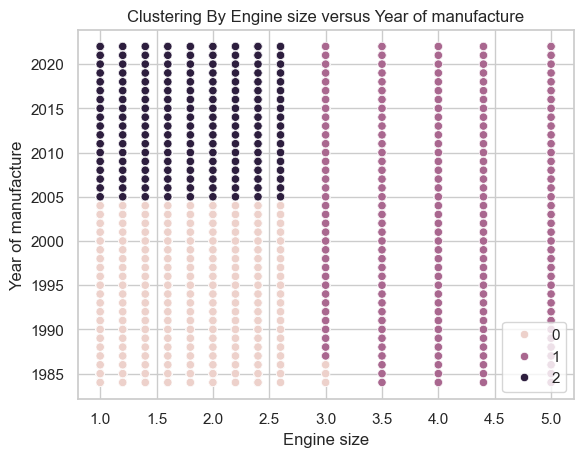

In [227]:
## Ploting using seaborn
sns.scatterplot(data = df, x = "Engine size", 
                y = "Year of manufacture", 
                hue =cluster_labels_pred
               )
# Add a legend to show the cluster labels
plt.legend(loc = "lower right")
# Label both axes
plt.xlabel("Engine size")
plt.ylabel("Year of manufacture")

plt.title('Clustering By Engine size versus Year of manufacture')
plt.savefig('Cluster_By_Engine_size_By_Year_of_manufacture.png', dpi=300, bbox_inches='tight')
# Show the figure
plt.show()


### Task 6.1
Now we would try the next combination, using mileage and price variable, to see how it perfoms and which is good

In [228]:
# Extract the input features
feature = ["Mileage", "Price"]
x = df[feature]

# Import the StandardScaler class from sklearn
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that
# we have in x. This will find the mean and standard
# deviation of each column in x.
scale.fit(x)

# Now we can apply the standard scaler transformation
# to re-scale each column in x.
x_scaled = scale.transform(x)

# Import the k-Means model
from sklearn.cluster import KMeans

# Create a list to record the inertia
# for each value of k.
inertia = []

# Define the range of values of k
# that we will use.

k_range = range(1, 11)
# Loop through the possible values of k
for k in k_range:
# Initialise the model
    kmeans = KMeans(n_clusters = k, random_state = 42)
# Fit the model to the scaled data
    kmeans.fit(x_scaled)
# Record the inertia
    inertia.append(kmeans.inertia_)

In [229]:
# Import the internal measures
from sklearn.metrics import davies_bouldin_score, silhouette_score
# Calculate the Davies-Bouldin index
db_score = davies_bouldin_score(x_scaled, cluster_labels_pred)
# Calculate the Silhouette coefficient
s_score = silhouette_score(x_scaled, cluster_labels_pred)
# Print the results
print("Davies Bouldin Index: %.4f" % (db_score, ))
print("Silhouette Coefficient: %.4f" % (s_score, ))

Davies Bouldin Index: 2.2420
Silhouette Coefficient: 0.3028


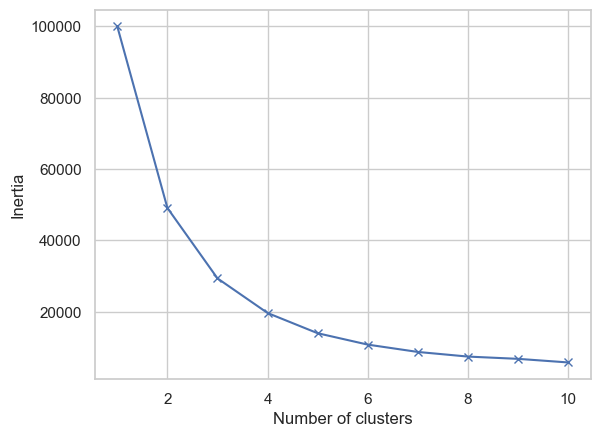

In [230]:
# Use matplotlib to plot the inertia versus k
plt.plot(k_range, inertia, 'bx-')
# Label the axes
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
# Show the figure
plt.show()

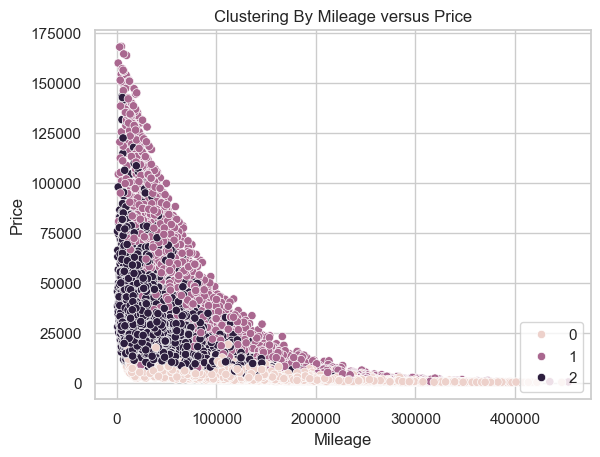

In [231]:
## Ploting using seaborn
sns.scatterplot(data = df, x = "Mileage", 
                y = "Price", 
                hue =cluster_labels_pred
               )
# Add a legend to show the cluster labels
plt.legend(loc = "lower right")
# Label both axes
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.title('Clustering By Mileage versus Price')
plt.savefig('Cluster_By_Mileage_and_Price.png', dpi=300, bbox_inches='tight')
# Show the figure
plt.show()

Using K-Means clustering on mileage and price, we identified three well-separated groups of cars. The scores was Davies Bouldin Index: 2.2420
Silhouette Coefficient: 0.3028 0.65, indicating strong cluster cohesion.
Clustering is not very good, but it’s not completely random either. You have some groupings, but clusters are overlapping or loosely defined. but the clustering and grouping seeems to be better than the combination of Engine size and year of manufacture


#### Task 6.3

We would be trying a combination of price, mileage and year of manufacture, to see how it performs

In [232]:

# SELECT FEATURES
features = ['Mileage', 'Year of manufacture', 'Price']
X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# FIND OPTIMAL NUMBER OF CLUSTERS

wcss = []
k_range = range(2, 11)  # trying 2 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)



# Silhouette scores for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Silhouette Score = {score:.3f}")


# FIT K-MEANS WITH OPTIMAL K
# Assume optimal k is 3 (based on elbow & silhouette)
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

k = 2, Silhouette Score = 0.488
k = 3, Silhouette Score = 0.417
k = 4, Silhouette Score = 0.404
k = 5, Silhouette Score = 0.376
k = 6, Silhouette Score = 0.350
k = 7, Silhouette Score = 0.337
k = 8, Silhouette Score = 0.337
k = 9, Silhouette Score = 0.319
k = 10, Silhouette Score = 0.314


In [233]:
# Import the internal measures
from sklearn.metrics import davies_bouldin_score, silhouette_score
# Calculate the Davies-Bouldin index
db_score = davies_bouldin_score(x_scaled, cluster_labels_pred)
# Calculate the Silhouette coefficient
s_score = silhouette_score(x_scaled, cluster_labels_pred)
# Print the results
print("Davies Bouldin Index: %.4f" % (db_score, ))
print("Silhouette Coefficient: %.4f" % (s_score, ))

Davies Bouldin Index: 2.2420
Silhouette Coefficient: 0.3028


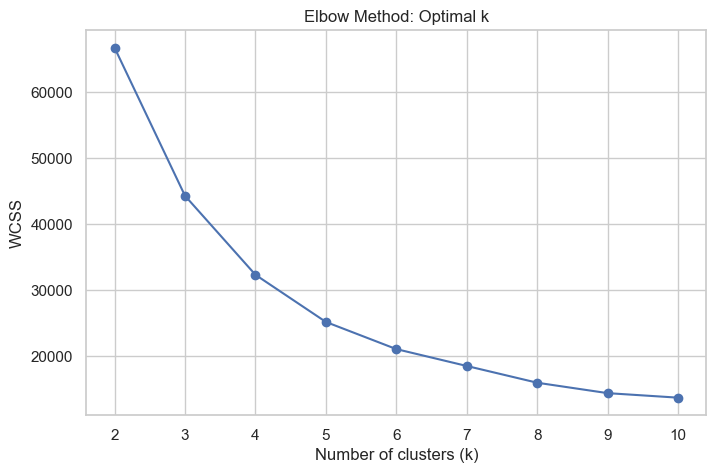

In [234]:
# Plot WCSS (Elbow Method)
plt.figure(figsize=(8,5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method: Optimal k")
plt.show()

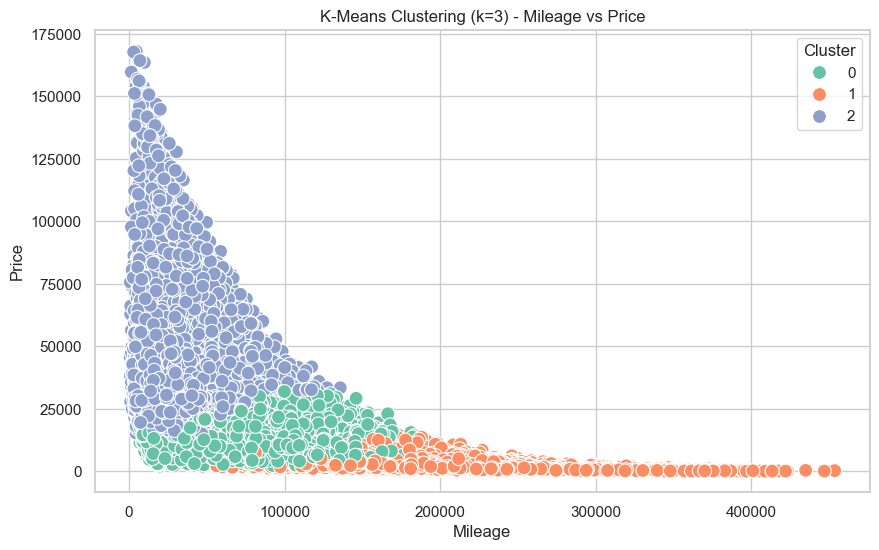

In [235]:

# VISUALIZE CLUSTERS
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Mileage',
    y='Price',
    hue='Cluster',
    palette='Set2',
    data=df,
    s=100
)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title(f"K-Means Clustering (k={k_opt}) - Mileage vs Price")

plt.legend(title="Cluster")
plt.savefig('Cluster_By_Mileage_and_Price.png', dpi=300, bbox_inches='tight')
plt.show()

K-Means clustering was applied to the car sales dataset using mileage, year of manufacture, and price as input variables. To determine the optimal number of clusters (k), the silhouette score was computed for values of k ranging from 2 to 10.

The results show that k = 2 achieved the highest silhouette score (0.488), indicating the most compact and well-separated clustering structure. As the number of clusters increased beyond two, the silhouette score steadily decreased, suggesting increased overlap between clusters and reduced cluster quality. This pattern indicates diminishing returns from adding additional clusters.

A silhouette score close to 0.5 suggests moderately good clustering, which is typical for real-world datasets such as car sales data, where features naturally overlap. The two-cluster solution likely represents a meaningful segmentation between lower-priced, older, high-mileage vehicles and higher-priced, newer, low-mileage vehicles.

Although solutions with k = 3 or k = 4 may provide more granular segmentation, they exhibit lower silhouette scores and therefore weaker separation. Based on both quantitative evaluation and interpretability, k = 2 was selected as the optimal number of clusters for this feature combination.

The clustering analysis demonstrates that mileage, year of manufacture, and price form an effective feature set for unsupervised segmentation of car sales data. Using the silhouette score as the primary evaluation metric, the two-cluster solution provides the best balance between cluster quality and interpretability, making it the most suitable choice for this dataset.

### Task 7 
Comparing clutering algorithm using K-means and DBSCAN, to see which perform  best

In [236]:
# Extract the input features
feature = ["Price", "Mileage"]
x = df[feature]

# Scale the input features
scale = StandardScaler()
scale.fit(x)
x_scaled = scale.transform(x)

# Import the DBSCAN model from sklearn.
from sklearn.cluster import DBSCAN
# Create an instance of the DBSCAN class, and
# set the eps and min_samples parameters.
dbscan = DBSCAN(eps=0.2, min_samples=3)
# Fit the model to the input data and output
# the predicted cluster labels from this model.
dbscan_labels_pred = dbscan.fit_predict(x_scaled)

 #Calculate the Davies-Bouldin index
db_score = davies_bouldin_score(x_scaled, dbscan_labels_pred)
# Calculate the Silhouette coefficient
s_score = silhouette_score(x_scaled, dbscan_labels_pred)
# Print the results
print("Davies Bouldin Index: %.4f" % (db_score, ))
print("Silhouette Coefficient: %.4f" % (s_score, ))

Davies Bouldin Index: 0.1570
Silhouette Coefficient: 0.8178


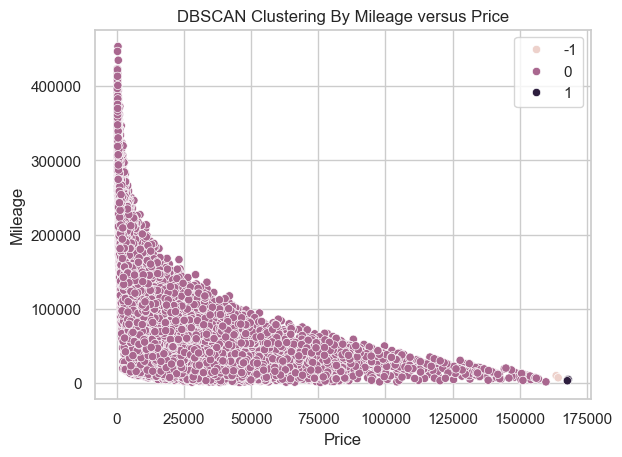

In [237]:
# Visualise the clusters
sns.scatterplot(data = df[feature],
                x = "Price", y = "Mileage", 
                hue = dbscan_labels_pred
               )
# Label both axes
plt.xlabel("Price")
plt.ylabel("Mileage")

plt.title('DBSCAN Clustering By Mileage versus Price')

plt.savefig('DBSCAN_Cluster_By_Mileage_and_Price.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

### Comparison of DBSCAN and k-Means Clustering

To further evaluate clustering performance using price, mileage, and year of manufacture, the DBSCAN algorithm was compared with the previously applied k-Means clustering model.

The comparison was based on internal validation metrics:
Silhouette Coefficient (higher values indicate better cluster separation)

Davies–Bouldin Index (lower values indicate better cluster compactness and separation)

The DBSCAN algorithm significantly outperforms k-Means clustering based on both evaluation metrics:

The very high Silhouette Coefficient (0.8178) indicates excellent separation between clusters, with data points strongly associated with their respective clusters.

The very low Davies–Bouldin Index (0.1570) suggests that DBSCAN produces highly compact clusters with minimal overlap.

In contrast, k-Means assumes spherical clusters and assigns every data point to a cluster, including outliers. This limitation reduces its effectiveness when the data contains noise, irregular cluster shapes, or varying densities, which are common in real-world car sales data.

DBSCAN is better suited to this dataset because, it does not require pre-defining the number of clusters, unlike k-Means, It identifies and excludes noise/outliers, improving cluster quality.
It handles non-spherical and unevenly distributed clusters, which aligns well with price and mileage patterns.

Based on the significantly higher Silhouette score and substantially lower Davies–Bouldin Index, DBSCAN produces the best clustering results for the given dataset. These results demonstrate that DBSCAN captures the underlying structure of the data more effectively than k-Means when clustering vehicles based on price, mileage, and year of manufacture.

## Exercise 2: Image Recognition to Identify Handwritten Digits

In [240]:
#Importing Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import the Mnist dataset
from tensorflow import keras
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [241]:
class_names = [str(i) for i in range(10)]

In [242]:
# Print the shape of each array.
print("x_train shape is:", x_train.shape)
print("x_test shape is:", x_test.shape)
print("y_train shape is:", y_train.shape)
print("y_test shape is:", y_test.shape)

x_train shape is: (60000, 28, 28)
x_test shape is: (10000, 28, 28)
y_train shape is: (60000,)
y_test shape is: (10000,)


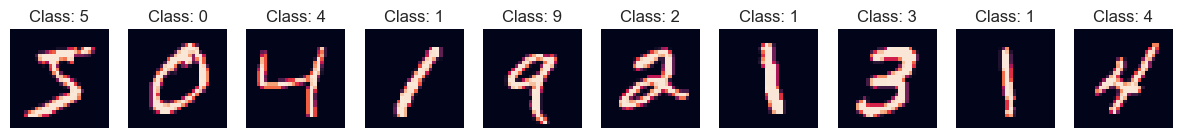

In [243]:
# Plot the first 9 images from the training set
fig, axs = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axs[i].imshow(x_train[i])
    axs[i].set_title(f"Class: {class_names[y_train[i]]}")
    axs[i].axis('off')
plt.show()


In [244]:
# This shows the shape of one of the train images (length, width, channel)
x_train[1].shape 

(28, 28)

In [245]:
np.unique(x_train[0])

array([  0,   1,   2,   3,   9,  11,  14,  16,  18,  23,  24,  25,  26,
        27,  30,  35,  36,  39,  43,  45,  46,  49,  55,  56,  64,  66,
        70,  78,  80,  81,  82,  90,  93,  94, 107, 108, 114, 119, 126,
       127, 130, 132, 133, 135, 136, 139, 148, 150, 154, 156, 160, 166,
       170, 171, 172, 175, 182, 183, 186, 187, 190, 195, 198, 201, 205,
       207, 212, 213, 219, 221, 225, 226, 229, 238, 240, 241, 242, 244,
       247, 249, 250, 251, 252, 253, 255], dtype=uint8)

In [246]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [247]:
#MinMax normalization
# Normalize pixel values to range between 0 and 1
# the pixel values in an image typically range from 0 to 255
# dividing all pixel values by 255 brings the pixel values to the range between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [248]:
x_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [249]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#For preprocessing, the ImageDataGenerator is used.
#It is used for the generation of batches of augmented image data
#in real-time during the training process;from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [250]:
from tensorflow.keras.utils import to_categorical

x_train = x_train[..., np.newaxis]  # shape: (60000, 28, 28, 1)
x_test  = x_test[..., np.newaxis]   # shape: (10000, 28, 28, 1)

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [251]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=10,      # rotate small angles
    width_shift_range=0.1,  # horizontal shift
    height_shift_range=0.1, # vertical shift
    zoom_range=0.1           # zoom in/out

)
# Fit the transformation to the training dataset
train_datagen.fit(x_train)



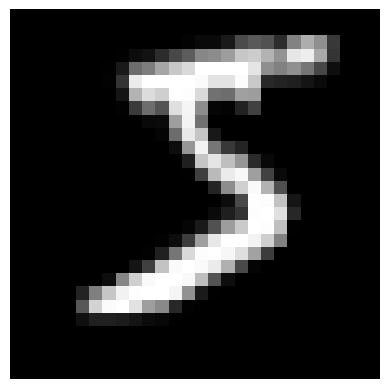

In [252]:
# Apply the random_transform function to the first image
# in the normalised training set, i.e. x_train_norm[0].
new_image = train_datagen.random_transform(x_train[0])
# Now use matplotlib to show this image.
plt.imshow(new_image, cmap = "gray")
# The following line of code will remove the
# axes from the image.
plt.gca().axis("off")
# Show the figure.
plt.show()

In [253]:
# Import the Sequential model from Tensor Flow
from tensorflow.keras.models import Sequential
# Import the layers that we will require from Tensor Flow

# Conv2D (for 2-dimensional convolutional layers),
# MaxPooling2D (for 2-dimensional pooling layers),
# and Flatten (to flatten the output from the last
# pooling layer ready to go into the fully connected part
# of the network).
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Create an instance of the Sequential class.
# This will be our model.
model = Sequential()

model.add(Input(shape=(28,28,1)))
model.add(Conv2D(filters=32,kernel_size=(3,3), activation = 'relu',padding = 'same'))
#Padding = 'same' to keep the output size equal to the input size after convolution by adding extra zeros
#model.add(Conv2D(filters=32,kernel_size=(3,3),input_shape=(32,32,3),activation = 'relu',padding = 'valid'))

# Add a pooling layer that uses max pooling,
# with a pool size of 2x2.
model.add(MaxPooling2D(pool_size=(2,2)))

# Add a second convolutional layer, again with a kernel size of 3x3 and
# the relu activation function but now with 64 filters. Note that it
# is common to increase the number of filters as we go deeper into
# the network.
model.add(Conv2D(filters=64,kernel_size=(3,3),activation = 'relu'))
# Add a second max pooling layer.
model.add(MaxPooling2D(pool_size=(2,2)))
# Add a third convolutional layer, now with 128 filters.
model.add(Conv2D(filters=128,kernel_size=(3,3),activation = 'relu'))
# Add a third max pooling layer.
model.add(MaxPooling2D(pool_size=(2,2)))
# After the final pooling layer, we need a flatten layer,
# which will flatten the output to a 1-dimensional array,
# ready for the fully connected network.
model.add(Flatten())
# Add a Dense (i.e. fully connected) layer with 64 neurons
# and the relu activation function.
model.add(Dense(64,activation = 'relu'))
# Apply a dropout rate of 50% to the dense layer.
model.add(Dropout(0.5))
# The output layer needs 10 units, corresponding

# output values will represent the probabilities
# for each of the 10 class labels.
model.add(Dense(10,activation = 'softmax'))
# Print a summary of the model.
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 126,154 (492.79 KB)

 Trainable params: 126,154 (492.79 KB)

 Non-trainable params: 0 (0.00 B)

In [254]:
print(y_train.shape)
print(np.unique(y_train))




(60000, 10)
[0. 1.]


In [255]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

# Compile model with SGD optimizer
model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_test, y_test)
)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.8427 - loss: 0.4828 - val_accuracy: 0.9811 - val_loss: 0.0524
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9549 - loss: 0.1588 - val_accuracy: 0.9876 - val_loss: 0.0394
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9660 - loss: 0.1205 - val_accuracy: 0.9892 - val_loss: 0.0355
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9714 - loss: 0.1004 - val_accuracy: 0.9919 - val_loss: 0.0261
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9755 - loss: 0.0896 - val_accuracy: 0.9929 - val_loss: 0.0247
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9774 - loss: 0.0817 - val_accuracy: 0.9898 - val_loss: 0.0304
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9799 - loss: 0.0729 - val_accuracy: 0.9929 - val_loss: 0.0254
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9808 -

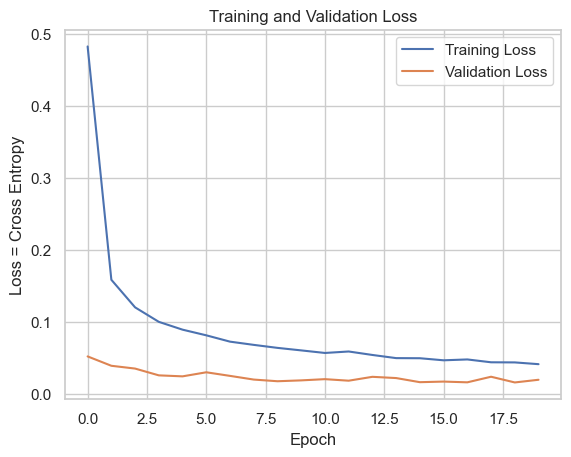

In [256]:
## checking for overfitting
# Plot training loss against validation loss
#Plots the training loss as a line with label "Training Loss".
plt.plot(history.history['loss'], label='Training Loss')
#Plots the validation loss as a line with label "Validation Loss".
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot to "Training and Validation Loss".
plt.title('Training and Validation Loss')
#Sets the label of the x-axis to "Epochs".
plt.xlabel('Epoch')
#Sets the label of the y-axis to "Loss".
plt.ylabel('Loss = Cross Entropy')
#Shows the legend of the plot with the labels of the two lines.
plt.legend()

plt.savefig('CNN TRAINIG & VALIDATION.png', dpi=300, bbox_inches='tight')
#Shows the plot on the screen.
plt.show()

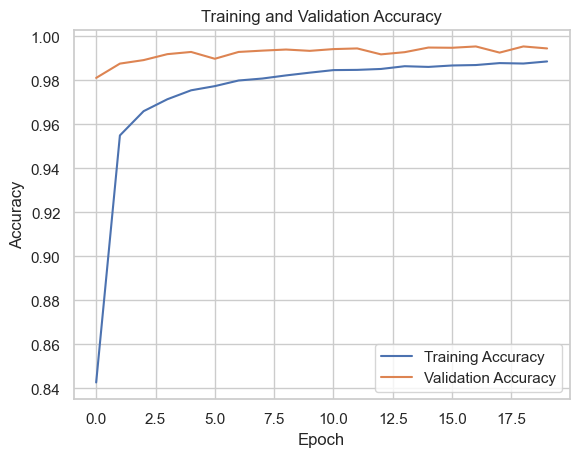

In [257]:
# Plot training and validation accuracy
#Plots the training accuracy as a line with label "Training Accuracy".
plt.plot(history.history['accuracy'], label='Training Accuracy')
#Plots the validation accuracy as a line with label "Validation Accuracy".
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot to "Training and Validation Accuracy".
plt.title('Training and Validation Accuracy')

#Sets the label of the x-axis to "Epochs".
plt.xlabel('Epoch')
#Sets the label of the y-axis to "Accuracy".
plt.ylabel('Accuracy')
#Shows the legend of the plot with the labels of the two lines.
plt.legend()

plt.savefig('CNN TRAINIG & VALIDATION ACCURACY.png', dpi=300, bbox_inches='tight')
#Shows the plot on the screen.
plt.show()

In [258]:
y_pred = np.argmax(model.predict(x_test), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [259]:
print(y_pred.shape)

(10000,)


In [260]:
from sklearn.metrics import classification_report

# Convert y_test from one-hot to class labels
y_test_labels = np.argmax(y_test, axis=1)

# y_pred is already class indices
y_pred_labels = y_pred

# Print classification report
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.99      1.00      1.00       958
           7       0.99      1.00      1.00      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



<Figure size 2000x2000 with 0 Axes>

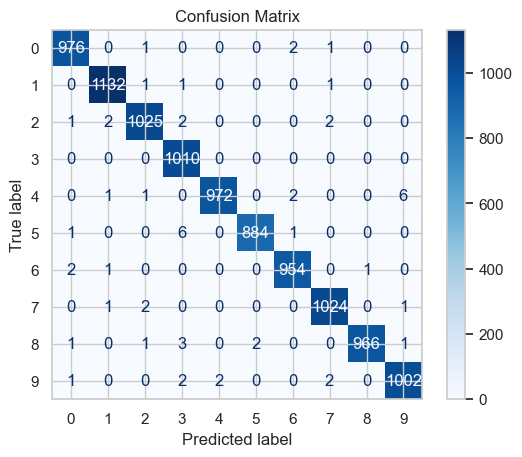

In [263]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(dpi=200, figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    y_test_labels,        # 1D array of true labels
    y_pred_labels,        # 1D array of predicted labels
    display_labels=class_names,
    cmap=plt.cm.Blues
)
plt.title('Confusion Matrix')

plt.savefig('Confusion Matrix.png', dpi=300, bbox_inches='tight')
plt.show()


From the training model, we discovered High training and validation accuracy:
Training: 98.76%
Validation: 99.38%
The model is performing extremely well, even slightly better on validation, which can happen due to regularization (dropout) or randomness in mini-batch training. Higher validation accuracy to accuracy shows no overfittig in the model and lower lose shows the model is actualy perfoming well

Low training and validation loss: Both losses are very low model is confident in its predictions.Typically overfitting shows as high training accuracy but lower validation accuracy.
Model is well-trained and generalizes to unseen data

### Task 7.2

Tuning some hyperparameters to see how the models performs in the presence of some tunned parameters

In [264]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Create the model
model = Sequential()

# Input layer
model.add(Input(shape=(28,28,1)))

# First Conv block
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())  # Tuned: added BatchNormalization for faster, stable training
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Conv block
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())  #BatchNormalization())  # Tuned: added BatchNormalization for faster, stable training
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Conv block
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())  # Tuned
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))  # Tuned: increased units from 64 → 128
model.add(Dropout(0.4))                   # Tuned: reduced dropout from 0.5 → 0.4 for slightly higher capacity

# Output layer
model.add(Dense(10, activation='softmax'))

# Compile with Adam optimizer (tuned)
model.compile(
    optimizer=Adam(learning_rate=0.001),  # ✅ Tuned: changed from SGD → Adam for faster convergence
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,522 (627.04 KB)

 Trainable params: 160,074 (625.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [265]:
print(y_train.shape)
print(np.unique(y_train))

(60000, 10)
[0. 1.]


In [266]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

# Compile model with SGD optimizer
model.compile(
    optimizer=SGD(learning_rate=0.5, momentum=0.7),   # Tuned learning_rate from 0.01 to 0.5 and momentum from 0.9  t0 0.7 ro check for 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_datagen.flow(x_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(x_test, y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - accuracy: 0.1043 - loss: 2.3653 - val_accuracy: 0.1135 - val_loss: 2.3177
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.1031 - loss: 2.3136 - val_accuracy: 0.1135 - val_loss: 2.3079
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.1027 - loss: 2.3127 - val_accuracy: 0.1032 - val_loss: 2.3110
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.1025 - loss: 2.3131 - val_accuracy: 0.0974 - val_loss: 2.3135
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.1003 - loss: 2.3131 - val_accuracy: 0.1028 - val_loss: 2.3065
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.1009 - loss: 2.3135 - val_accuracy: 0.1135 - val_loss: 2.3083
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.1011 - loss: 2.3138 - val_accuracy: 0.1010 - val_loss: 2.3210
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.1041 -

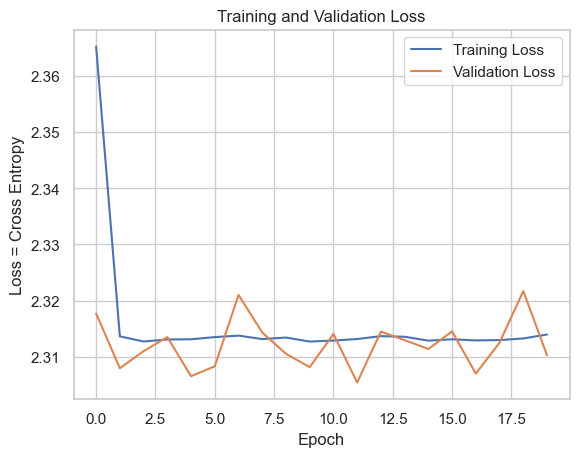

In [267]:
## checking for overfitting
# Plot training loss against validation loss
#Plots the training loss as a line with label "Training Loss".
plt.plot(history.history['loss'], label='Training Loss')
#Plots the validation loss as a line with label "Validation Loss".
plt.plot(history.history['val_loss'], label='Validation Loss')
#Sets the title of the plot to "Training and Validation Loss".
plt.title('Training and Validation Loss')
#Sets the label of the x-axis to "Epochs".
plt.xlabel('Epoch')
#Sets the label of the y-axis to "Loss".
plt.ylabel('Loss = Cross Entropy')
#Shows the legend of the plot with the labels of the two lines.
plt.legend()

plt.savefig('TUNED CNN TRAINIG & VALIDATION.png', dpi=300, bbox_inches='tight')
#Shows the plot on the screen.
plt.show()

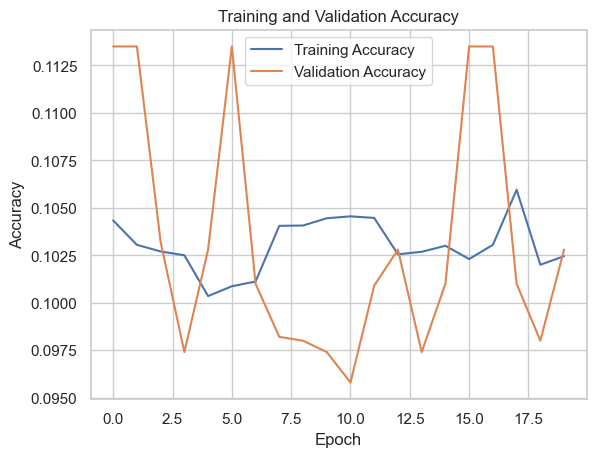

In [268]:
# Plot training and validation accuracy
#Plots the training accuracy as a line with label "Training Accuracy".
plt.plot(history.history['accuracy'], label='Training Accuracy')
#Plots the validation accuracy as a line with label "Validation Accuracy".
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
#Sets the title of the plot to "Training and Validation Accuracy".
plt.title('Training and Validation Accuracy')

#Sets the label of the x-axis to "Epochs".
plt.xlabel('Epoch')
#Sets the label of the y-axis to "Accuracy".
plt.ylabel('Accuracy')
#Shows the legend of the plot with the labels of the two lines.
plt.legend()

plt.savefig('TUNED CNN TRAINIG & VALIDATION ACCURACY.png', dpi=300, bbox_inches='tight')
#Shows the plot on the screen.
plt.show()

In [269]:
y_pred = np.argmax(model.predict(x_test), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [270]:
from sklearn.metrics import classification_report

# Convert y_test from one-hot to class labels
y_test_labels = np.argmax(y_test, axis=1)

# y_pred is already class indices
y_pred_labels = y_pred

# Print classification report
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.00      0.00      0.00      1135
           2       0.00      0.00      0.00      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.00      0.00      0.00       892
           6       0.00      0.00      0.00       958
           7       0.10      1.00      0.19      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

<Figure size 2000x2000 with 0 Axes>

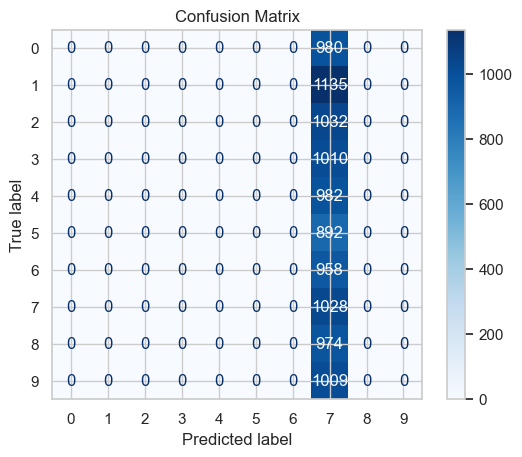

In [273]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(dpi=200, figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    y_test_labels,        # 1D array of true labels
    y_pred_labels,        # 1D array of predicted labels
    display_labels=class_names,
    cmap=plt.cm.Blues
)
plt.title('Confusion Matrix')

plt.savefig('Tuned Confusion Matrix.png', dpi=300, bbox_inches='tight')
plt.show()